# Master Thesis - Vignoli Lorenzo

---

## 🐙 Helyx control results

## ⚙️ Import Libraries

In [1]:
# Libraries
import os
import glob
import random
import warnings
import numpy as np # type: ignore
from sklearn.model_selection import train_test_split # type: ignore

import torch # type: ignore
import torch.nn as nn # type: ignore
import torch.optim as optim # type: ignore
from torch.utils.data import Dataset, DataLoader, RandomSampler # type: ignore
import torch.nn.functional as F # type: ignore
import shutil
import plotly.graph_objects as go # type: ignore
from torch.optim.lr_scheduler import LinearLR, ReduceLROnPlateau # type: ignore
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
import matplotlib as mpl # type: ignore
from matplotlib import rcParams # type: ignore
from cycler import cycler # type: ignore
import sys
from torch.amp import GradScaler, autocast # type: ignore
import pandas as pd # type: ignore

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from scipy.spatial.transform import Rotation as R
from scipy.linalg import solve
from numpy.linalg import lstsq
from scipy.linalg import null_space
import torchvision.models as models
from torchvision.models import mobilenet_v2
from tqdm import tqdm # type: ignore
from scipy.integrate import cumulative_trapezoid
from matplotlib import gridspec
from sklearn.cluster import KMeans # type: ignore
import matplotlib

# Reconstruction utility
from SINGLE_reconstruction_utility import *

# PCC model
from SINGLE_jacobians import *
from SINGLE_kinematics import *

# Publication-ready plotting setup with TRUE LaTeX rendering
rcParams.update({
   'figure.figsize': (6, 4), 'figure.dpi': 300, 'savefig.dpi': 300,
   'savefig.format': 'pdf', 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
   'font.family': 'serif', 'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
   'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
   'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
   'lines.linewidth': 1.5, 'lines.markersize': 6, 'lines.markeredgewidth': 0.5,
   'axes.linewidth': 1.0, 'axes.spines.top': False, 'axes.spines.right': False,
   'axes.grid': True, 'axes.edgecolor': 'black',  # Fixed: 'edgecolo' -> 'edgecolor'
   'xtick.direction': 'in', 'ytick.direction': 'in',
   'xtick.major.size': 4, 'ytick.major.size': 4,
   'xtick.minor.size': 2, 'ytick.minor.size': 2,
   'xtick.minor.visible': True, 'ytick.minor.visible': True,
   'grid.color': 'gray', 'grid.linestyle': '-', 'grid.linewidth': 0.5, 'grid.alpha': 0.3,  # Fixed: 'grid.colo' -> 'grid.color'
   'legend.frameon': True, 'legend.framealpha': 0.9, 'legend.fancybox': False,
   'legend.edgecolor': 'black', 'legend.facecolor': 'white', 'legend.numpoints': 1,  # Fixed: 'edgecolo' -> 'edgecolor', 'facecolo' -> 'facecolor'
   'text.usetex': True,  # TRUE LaTeX rendering
   'mathtext.default': 'regular',  # Fixed: 'regula' -> 'regular'
   'axes.unicode_minus': False,
   'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'  # Added raw string prefix
})

sns.set_style("whitegrid", {"axes.spines.left": True, "axes.spines.bottom": True,
                          "axes.spines.top": False, "axes.spines.right": False,
                          "grid.color": "0.8", "grid.linestyle": "-", "grid.linewidth": 0.5})
pub_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
             '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(pub_colors)
rcParams['axes.prop_cycle'] = cycler('color', pub_colors)  # Fixed: 'colo' -> 'color'

# Ignore warnings
warnings.filterwarnings("ignore")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


(Save) and Plot Control Workspace

In [2]:
def SaveControlWorkspace():
    """
    Saves control workspace using deterministic k-means for maximum coverage.
    Only considers points with z > 110. Uses deterministic initialization from actual workspace points.
    """
    
    WS = np.load("Workspace.npz")["xyz"]  # Load with correct key
    
    # Filter points with z > 115
    valid_mask = WS[:, 2] > 115
    valid_WS = WS[valid_mask]
    
    n_points = 20
    
    # Deterministic initialization: select evenly spaced points from workspace
    init_indices = np.linspace(0, len(valid_WS)-1, n_points, dtype=int)
    init_centers = valid_WS[init_indices]
    
    # Use k-means with custom initialization
    kmeans = KMeans(n_clusters=n_points, init=init_centers, n_init=1, random_state=42)
    clusters = kmeans.fit(valid_WS)
    
    ControlWorkspace = []
    for centroid in clusters.cluster_centers_:
        # Find closest actual point to each centroid
        distances = np.linalg.norm(valid_WS - centroid, axis=1)
        closest_idx = np.argmin(distances)
        ControlWorkspace.append(valid_WS[closest_idx])
    
    np.savez_compressed("ControlWorkspace.npz", xyz=ControlWorkspace)  # Save with same key structure

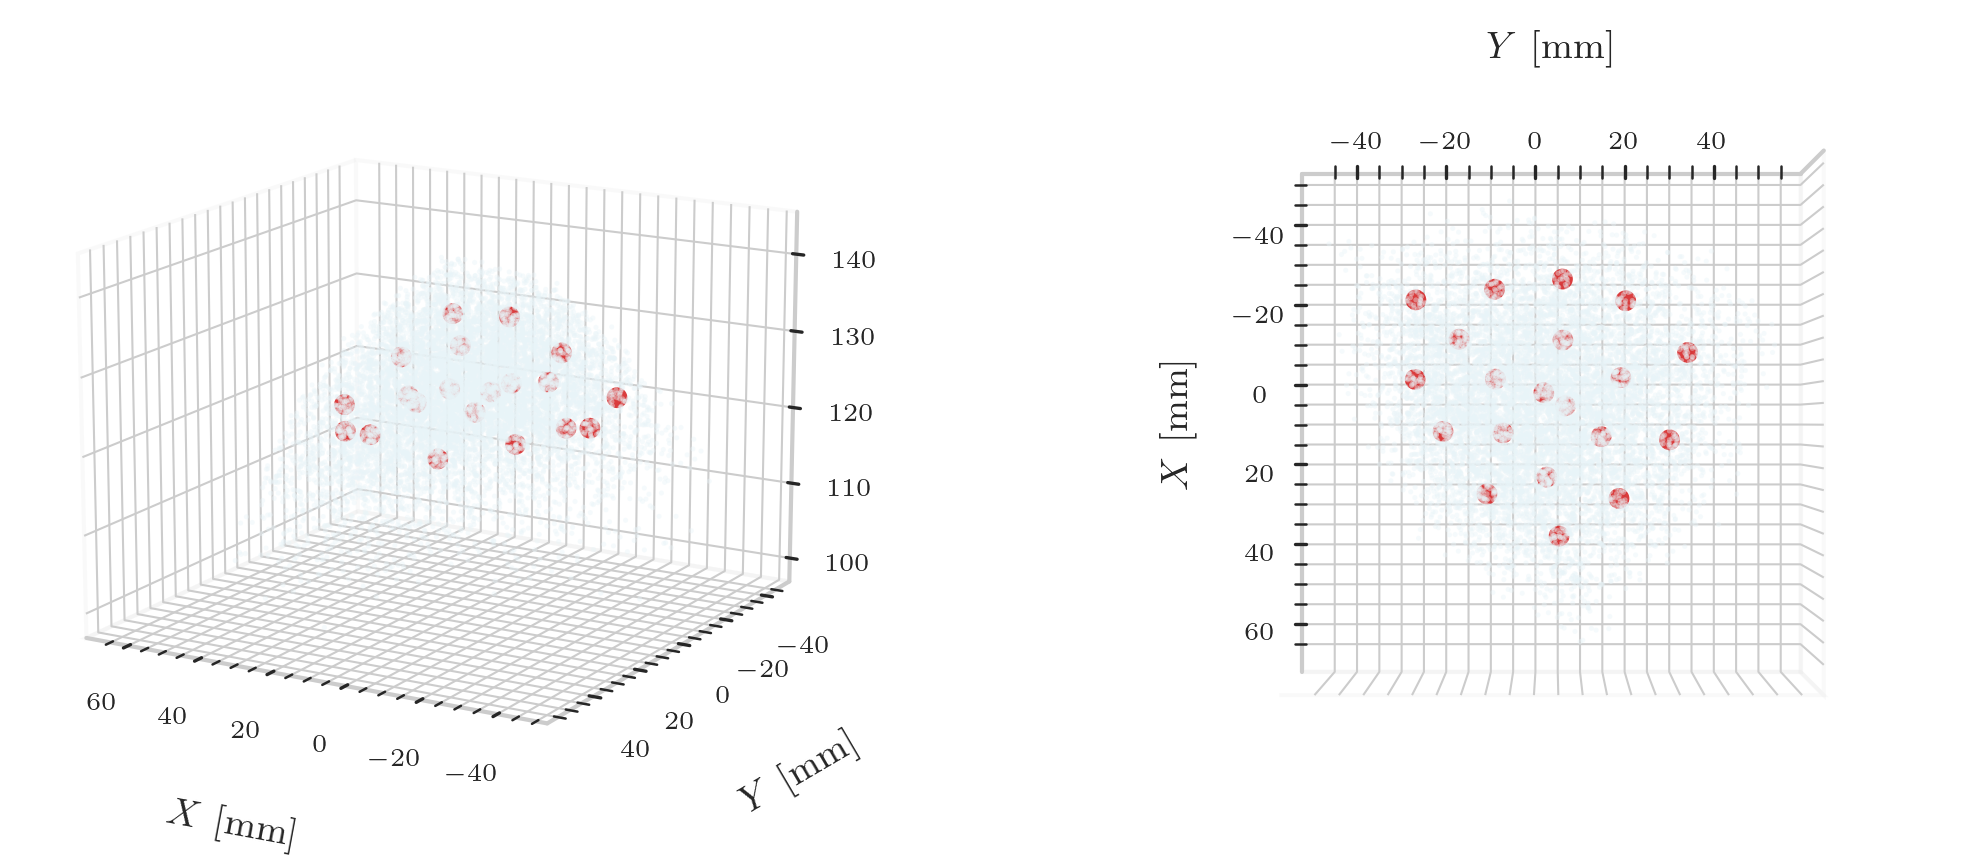

In [3]:
def plot_workspace():
    """
    Plot full workspace and selected control points in 3D from multiple perspectives.
    """
    # Load data with correct keys
    full_workspace = np.load("Workspace.npz")["xyz"]
    control_workspace = np.load("ControlWorkspace.npz")["xyz"]

    # Temporarily adjust rcParams for 3D plotting
    original_figsize = matplotlib.rcParams['figure.figsize']
    original_grid = matplotlib.rcParams['axes.grid']
    original_spines_top = matplotlib.rcParams['axes.spines.top']
    original_spines_right = matplotlib.rcParams['axes.spines.right']

    matplotlib.rcParams.update({
        'figure.figsize': (8, 3.5),
        'axes.grid': False,
        'axes.spines.top': True,
        'axes.spines.right': True
    })

    fig = plt.figure(figsize=(8, 3.5))

    # Default 3D view
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(full_workspace[:, 0], full_workspace[:, 1], full_workspace[:, 2], 
                c='#E8F4F8', alpha=0.4, s=1.5, edgecolors='none', rasterized=True)
    ax1.scatter(control_workspace[:, 0], control_workspace[:, 1], control_workspace[:, 2], 
                c='#d62728', s=25, alpha=0.9, edgecolors='none', rasterized=True)
    ax1.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9, labelpad=6)
    ax1.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9, labelpad=6)
    # Remove Z-axis label
    ax1.set_zlabel('')
    ax1.tick_params(labelsize=6, pad=1)
    ax1.view_init(elev=15, azim=120)

    # Top view (looking down) - remove Z axis numbers and label
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(full_workspace[:, 0], full_workspace[:, 1], full_workspace[:, 2], 
                c='#E8F4F8', alpha=0.4, s=1.5, edgecolors='none', rasterized=True)
    ax2.scatter(control_workspace[:, 0], control_workspace[:, 1], control_workspace[:, 2], 
                c='#d62728', s=25, alpha=0.9, edgecolors='none', rasterized=True)
    ax2.view_init(elev=90, azim=0)
    ax2.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9, labelpad=6)
    ax2.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9, labelpad=6)
    ax2.set_zticks([])
    ax2.set_zlabel('')
    ax2.tick_params(labelsize=6, pad=1)

    # Clean 3D panes styling for both subplots
    for ax in [ax1, ax2]:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('#cccccc')
        ax.yaxis.pane.set_edgecolor('#cccccc')
        ax.zaxis.pane.set_edgecolor('#cccccc')
        ax.xaxis.pane.set_alpha(0.1)
        ax.yaxis.pane.set_alpha(0.1)
        ax.zaxis.pane.set_alpha(0.1)
        ax.grid(True, alpha=0.15, linewidth=0.2)

    # Adjust layout with minimal spacing
    plt.subplots_adjust(left=0.05, right=0.95, wspace=0.05)

    # Restore original rcParams
    matplotlib.rcParams.update({
        'figure.figsize': original_figsize,
        'axes.grid': original_grid,
        'axes.spines.top': original_spines_top,
        'axes.spines.right': original_spines_right
    })

    plt.show()

# Plot workspace with control points
plot_workspace()

Workspace plotting - CL

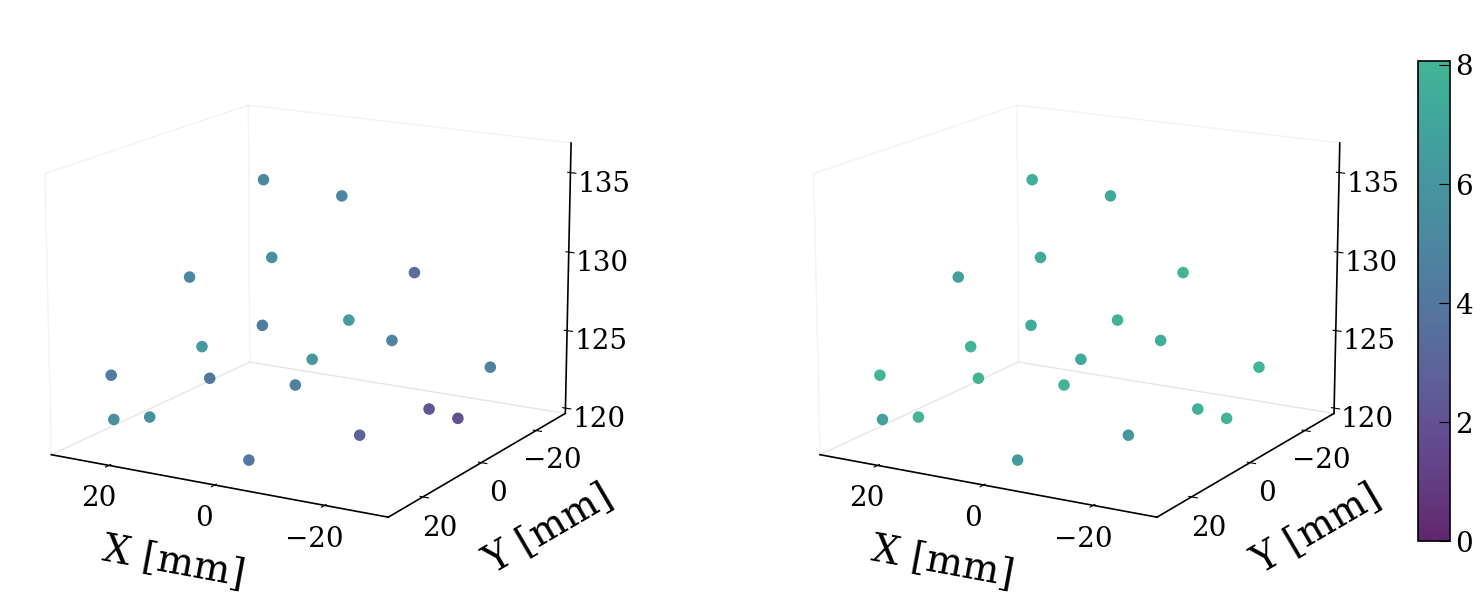


--- Error Summary Comparison ---
Jacobian     - Mean: 4.63 mm, Std: 1.24 mm
Data-driven  - Mean: 7.49 mm, Std: 0.57 mm


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm
import matplotlib.colors

# Load jacobian data
data_jac = np.load("ControlWorkspace_jacobian.npz")
target_jac = data_jac["target"]
mocap_jac = data_jac["mocap"]
error_jac = np.linalg.norm(target_jac - mocap_jac, axis=1)

# Load datadriven data
data_dd = np.load("ControlWorkspace_datadriven.npz")
target_dd = data_dd["target"]
mocap_dd = data_dd["mocap"]
error_dd = np.linalg.norm(target_dd - mocap_dd, axis=1)

# Use shared colorbar range
vmax = max(np.max(error_jac), np.max(error_dd))

# Truncate viridis colormap for better contrast
orig_cmap = matplotlib.cm.get_cmap('viridis')
trunc_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'trunc_viridis', orig_cmap(np.linspace(0, 0.6, 256))
)

# Configure matplotlib for publication quality
plt.rcParams.update({
  'font.size': 28,
  'font.family': 'serif',
  'axes.linewidth': 1.2,
  'xtick.major.size': 8,
  'xtick.minor.size': 2,
  'ytick.major.size': 8,
  'ytick.minor.size': 2,
  'xtick.direction': 'in',
  'ytick.direction': 'in'
})

# Create figure
fig = plt.figure(figsize=(16, 8))

# Jacobian plot (left)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(target_jac[:, 0], target_jac[:, 1], target_jac[:, 2],
                  c=error_jac, cmap=trunc_cmap, s=69, vmin=0, vmax=vmax,
                  alpha=0.85, edgecolors='none', rasterized=True)
ax1.set_xlabel(r'X [mm]', fontsize=28, labelpad=22)
ax1.set_ylabel(r'Y [mm]', fontsize=28, labelpad=22)
ax1.view_init(elev=15, azim=120)
ax1.set_xlim(-30, 30)
ax1.set_ylim(-30, 30)
ax1.set_xticks(np.arange(-20, 21, 20))
ax1.set_yticks(np.arange(-20, 21, 20))

# Z-axis ticks
z_min = max(115, int(np.min(target_jac[:, 2])))
z_max = int(np.max(target_jac[:, 2]))
z_ticks = np.arange(z_min, z_max + 5, 5)
ax1.set_zticks(z_ticks)

ax1.tick_params(axis='x', labelsize=20, pad=3)
ax1.tick_params(axis='y', labelsize=20, pad=3)
ax1.tick_params(axis='z', labelsize=20, pad=7)
ax1.grid(False)

# Clean 3D panes styling
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('gray')
    axis.pane.set_alpha(0.1)

# Datadriven plot (right)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(target_dd[:, 0], target_dd[:, 1], target_dd[:, 2],
                  c=error_dd, cmap=trunc_cmap, s=69, vmin=0, vmax=vmax,
                  alpha=0.85, edgecolors='none', rasterized=True)
ax2.set_xlabel(r'X [mm]', fontsize=28, labelpad=22)
ax2.set_ylabel(r'Y [mm]', fontsize=28, labelpad=22)
ax2.view_init(elev=15, azim=120)
ax2.set_xlim(-30, 30)
ax2.set_ylim(-30, 30)
ax2.set_xticks(np.arange(-20, 21, 20))
ax2.set_yticks(np.arange(-20, 21, 20))

# Z-axis ticks
z_min = max(115, int(np.min(target_dd[:, 2])))
z_max = int(np.max(target_dd[:, 2]))
z_ticks = np.arange(z_min, z_max + 5, 5)
ax2.set_zticks(z_ticks)

ax2.tick_params(axis='x', labelsize=20, pad=3)
ax2.tick_params(axis='y', labelsize=20, pad=3)
ax2.tick_params(axis='z', labelsize=20, pad=7)
ax2.grid(False)

# Clean 3D panes styling
for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('gray')
    axis.pane.set_alpha(0.1)

# Shared colorbar
cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
cbar = fig.colorbar(sc1, cax=cbar_ax)
cbar.ax.tick_params(labelsize=20)

# Adjust layout
plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3)
plt.show()

# Reset matplotlib parameters
plt.rcdefaults()

# Summary statistics
mean_error_jac = np.mean(error_jac)
std_error_jac = np.std(error_jac)
mean_error_dd = np.mean(error_dd)
std_error_dd = np.std(error_dd)

print(f"\n--- Error Summary Comparison ---")
print(f"Jacobian     - Mean: {mean_error_jac:.2f} mm, Std: {std_error_jac:.2f} mm")
print(f"Data-driven  - Mean: {mean_error_dd:.2f} mm, Std: {std_error_dd:.2f} mm")


Workspace plotting - OL

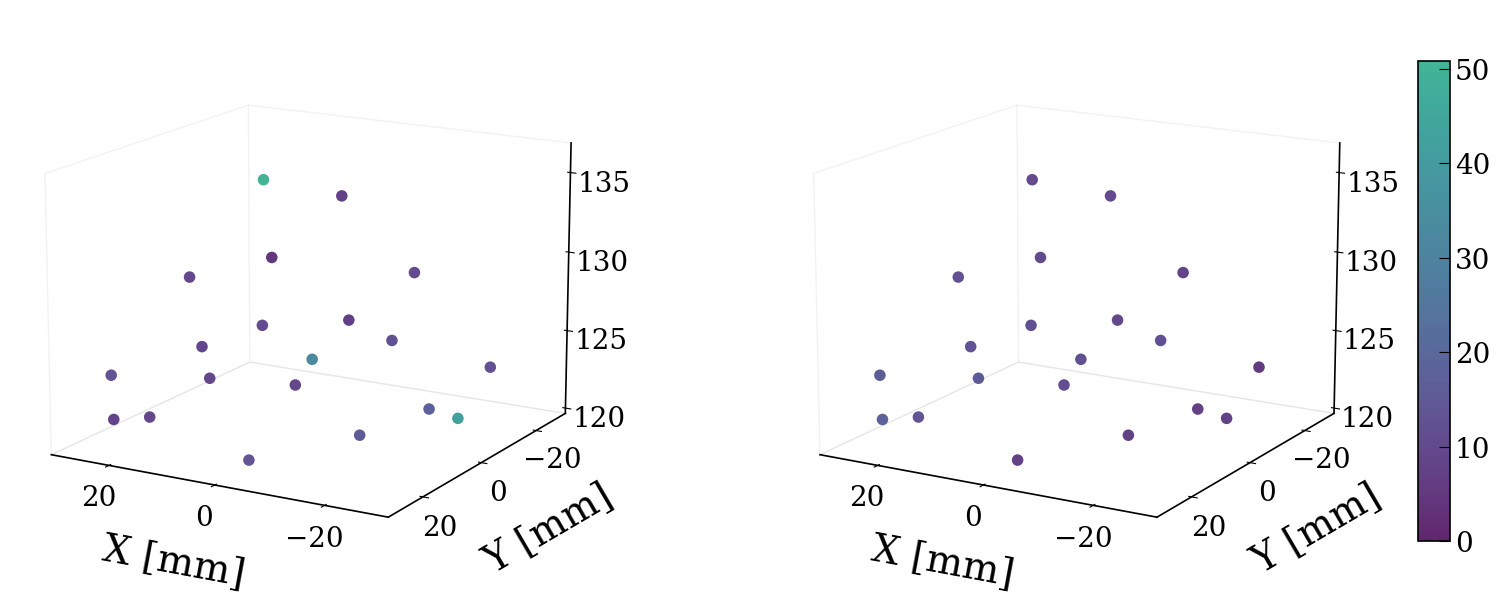


--- Error Summary Comparison ---
Jacobian     - Mean: 15.34 mm, Std: 11.88 mm
Data-driven  - Mean: 11.03 mm, Std: 3.20 mm


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm
import matplotlib.colors

# Load jacobian data
data_jac = np.load("ControlWorkspace_OL_jacobian.npz")
target_jac = data_jac["target"]
mocap_jac = data_jac["mocap"]
error_jac = np.linalg.norm(target_jac - mocap_jac, axis=1)

# Load datadriven data
data_dd = np.load("ControlWorkspace_OL_datadriven.npz")
target_dd = data_dd["target"]
mocap_dd = data_dd["mocap"]
error_dd = np.linalg.norm(target_dd - mocap_dd, axis=1)

# Use shared colorbar range
vmax = max(np.max(error_jac), np.max(error_dd))

# Truncate viridis colormap for better contrast
orig_cmap = matplotlib.cm.get_cmap('viridis')
trunc_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'trunc_viridis', orig_cmap(np.linspace(0, 0.6, 256))
)

# Configure matplotlib for publication quality
plt.rcParams.update({
  'font.size': 28,
  'font.family': 'serif',
  'axes.linewidth': 1.2,
  'xtick.major.size': 8,
  'xtick.minor.size': 2,
  'ytick.major.size': 8,
  'ytick.minor.size': 2,
  'xtick.direction': 'in',
  'ytick.direction': 'in'
})

# Create figure
fig = plt.figure(figsize=(16, 8))

# Jacobian plot (left)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(target_jac[:, 0], target_jac[:, 1], target_jac[:, 2],
                  c=error_jac, cmap=trunc_cmap, s=69, vmin=0, vmax=vmax,
                  alpha=0.85, edgecolors='none', rasterized=True)
ax1.set_xlabel(r'X [mm]', fontsize=28, labelpad=22)
ax1.set_ylabel(r'Y [mm]', fontsize=28, labelpad=22)
ax1.view_init(elev=15, azim=120)
ax1.set_xlim(-30, 30)
ax1.set_ylim(-30, 30)
ax1.set_xticks(np.arange(-20, 21, 20))
ax1.set_yticks(np.arange(-20, 21, 20))

# Z-axis ticks
z_min = max(115, int(np.min(target_jac[:, 2])))
z_max = int(np.max(target_jac[:, 2]))
z_ticks = np.arange(z_min, z_max + 5, 5)
ax1.set_zticks(z_ticks)

ax1.tick_params(axis='x', labelsize=20, pad=3)
ax1.tick_params(axis='y', labelsize=20, pad=3)
ax1.tick_params(axis='z', labelsize=20, pad=7)
ax1.grid(False)

# Clean 3D panes styling
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('gray')
    axis.pane.set_alpha(0.1)

# Datadriven plot (right)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(target_dd[:, 0], target_dd[:, 1], target_dd[:, 2],
                  c=error_dd, cmap=trunc_cmap, s=69, vmin=0, vmax=vmax,
                  alpha=0.85, edgecolors='none', rasterized=True)
ax2.set_xlabel(r'X [mm]', fontsize=28, labelpad=22)
ax2.set_ylabel(r'Y [mm]', fontsize=28, labelpad=22)
ax2.view_init(elev=15, azim=120)
ax2.set_xlim(-30, 30)
ax2.set_ylim(-30, 30)
ax2.set_xticks(np.arange(-20, 21, 20))
ax2.set_yticks(np.arange(-20, 21, 20))

# Z-axis ticks
z_min = max(115, int(np.min(target_dd[:, 2])))
z_max = int(np.max(target_dd[:, 2]))
z_ticks = np.arange(z_min, z_max + 5, 5)
ax2.set_zticks(z_ticks)

ax2.tick_params(axis='x', labelsize=20, pad=3)
ax2.tick_params(axis='y', labelsize=20, pad=3)
ax2.tick_params(axis='z', labelsize=20, pad=7)
ax2.grid(False)

# Clean 3D panes styling
for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('gray')
    axis.pane.set_alpha(0.1)

# Shared colorbar
cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
cbar = fig.colorbar(sc1, cax=cbar_ax)
cbar.ax.tick_params(labelsize=20)

# Adjust layout
plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3)
plt.show()

# Reset matplotlib parameters
plt.rcdefaults()

# Summary statistics
mean_error_jac = np.mean(error_jac)
std_error_jac = np.std(error_jac)
mean_error_dd = np.mean(error_dd)
std_error_dd = np.std(error_dd)

print(f"\n--- Error Summary Comparison ---")
print(f"Jacobian     - Mean: {mean_error_jac:.2f} mm, Std: {std_error_jac:.2f} mm")
print(f"Data-driven  - Mean: {mean_error_dd:.2f} mm, Std: {std_error_dd:.2f} mm")


## Workspace - datadriven control

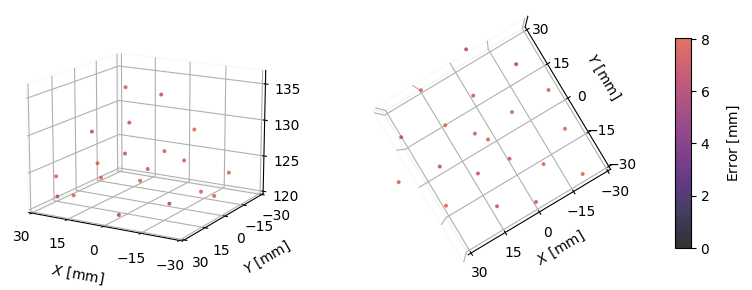


--- Error Summary (Target vs Mocap, datadriven) ---
Mean Error: 7.49 mm
Standard Deviation: 0.57 mm


In [5]:
# Load data
data = np.load("ControlWorkspace_datadriven.npz")
target = data["target"]
mocap = data["mocap"]
# Compute error vs mocap
error_mocap = np.linalg.norm(target - mocap, axis=1)
vmax = np.max(error_mocap)
# Truncate the colormap to first 60% for better contrast
orig_cmap = matplotlib.cm.get_cmap('inferno')
trunc_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'trunc_inferno', orig_cmap(np.linspace(0, 0.6, 256))
)
# Create publication-quality figure
fig = plt.figure(figsize=(8, 3.5))
# ---------------------------
# Plot 1: 3D Perspective View
# ---------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax1.scatter(target[:, 0], target[:, 1], target[:, 2],
                 c=error_mocap, cmap=trunc_cmap, s=8, vmin=0, vmax=vmax,
                 alpha=0.8, edgecolors='none', rasterized=True)
ax1.set_xlabel(r'$X~[\mathrm{mm}]$', labelpad=6)
ax1.set_ylabel(r'$Y~[\mathrm{mm}]$', labelpad=6)
ax1.view_init(elev=15, azim=120)
# Set X and Y axis limits and ticks
ax1.set_xlim(-30, 30)
ax1.set_ylim(-30, 30)
ax1.set_xticks(np.arange(-30, 31, 15))
ax1.set_yticks(np.arange(-30, 31, 15))
ax1.tick_params(axis='x', pad=2)
ax1.tick_params(axis='y', pad=2)
ax1.tick_params(axis='z', pad=2)
# Set Z-axis ticks every 5mm starting from 115
z_min = max(115, int(np.min(target[:, 2])))
z_max = int(np.max(target[:, 2]))
z_ticks = np.arange(z_min, z_max + 5, 5)
ax1.set_zticks(z_ticks)
# Clean 3D panes styling
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#cccccc')
    axis.pane.set_alpha(0.1)
ax1.grid(True, alpha=0.3, linewidth=0.5)
# ---------------------------
# Plot 2: Top-down View
# ---------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(target[:, 0], target[:, 1], target[:, 2],
            c=error_mocap, cmap=trunc_cmap, s=8, vmin=0, vmax=vmax,
            alpha=0.8, edgecolors='none', rasterized=True)
ax2.set_xlabel(r'$X~[\mathrm{mm}]$', labelpad=6)
ax2.set_ylabel(r'$Y~[\mathrm{mm}]$', labelpad=6)
ax2.set_zticks([])
ax2.set_zlabel('')
ax2.view_init(elev=-90, azim=120)
# Set X and Y axis limits and ticks for top-down view
ax2.set_xlim(-30, 30)
ax2.set_ylim(-30, 30)
ax2.set_xticks(np.arange(-30, 31, 15))
ax2.set_yticks(np.arange(-30, 31, 15))
ax2.tick_params(axis='x', pad=2)
ax2.tick_params(axis='y', pad=2)
# Match styling for second plot
for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#cccccc')
    axis.pane.set_alpha(0.1)
ax2.grid(True, alpha=0.3, linewidth=0.5)
# ---------------------------
# Publication-quality colorbar
# ---------------------------
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label(r'$\mathrm{Error}~[\mathrm{mm}]$', labelpad=12)
cbar.ax.tick_params()
# Adjust layout with minimal spacing
plt.subplots_adjust(left=0.05, right=0.9, wspace=0.05)
plt.show()
# ---------------------------
# Summary statistics
# ---------------------------
mean_error = np.mean(error_mocap)
std_error = np.std(error_mocap)
print(f"\n--- Error Summary (Target vs Mocap, datadriven) ---")
print(f"Mean Error: {mean_error:.2f} mm")
print(f"Standard Deviation: {std_error:.2f} mm")

## Workspace - Jacobian-based control

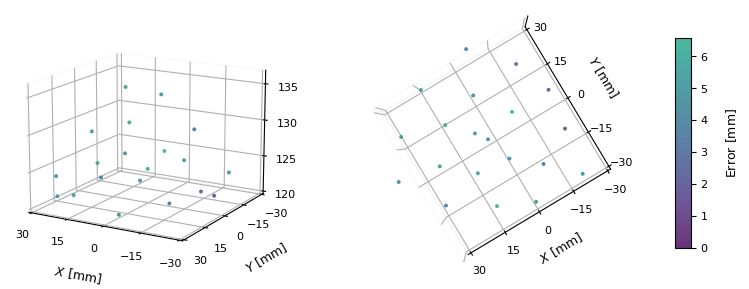


--- Error Summary (Target vs Mocap, jacobian) ---
Mean Error: 4.63 mm
Standard Deviation: 1.24 mm


In [6]:
# Load data
data = np.load("ControlWorkspace_jacobian.npz")
target = data["target"]
mocap = data["mocap"]

# Compute error vs mocap
error_mocap = np.linalg.norm(target - mocap, axis=1)
vmax = np.max(error_mocap)

# Truncate the colormap to first 60% for better contrast
orig_cmap = matplotlib.cm.get_cmap('viridis')
trunc_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'trunc_viridis', orig_cmap(np.linspace(0, 0.6, 256))
)

# Temporarily adjust rcParams for 3D plotting
original_figsize = matplotlib.rcParams['figure.figsize']
original_grid = matplotlib.rcParams['axes.grid']
original_spines_top = matplotlib.rcParams['axes.spines.top']
original_spines_right = matplotlib.rcParams['axes.spines.right']

matplotlib.rcParams.update({
    'figure.figsize': (8, 3.5),
    'axes.grid': False,
    'axes.spines.top': True,
    'axes.spines.right': True
})

# Create publication-quality figure
fig = plt.figure(figsize=(8, 3.5))

# ---------------------------
# Plot 1: 3D Perspective View
# ---------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax1.scatter(target[:, 0], target[:, 1], target[:, 2],
                 c=error_mocap, cmap=trunc_cmap, s=8, vmin=0, vmax=vmax, 
                 alpha=0.8, edgecolors='none', rasterized=True)

ax1.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9, labelpad=6)
ax1.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9, labelpad=6)
ax1.view_init(elev=15, azim=120)
# Set X and Y axis limits and ticks
ax1.set_xlim(-30, 30)
ax1.set_ylim(-30, 30)
ax1.set_xticks(np.arange(-30, 31, 15))
ax1.set_yticks(np.arange(-30, 31, 15))
ax1.tick_params(axis='x', labelsize=8, pad=2)
ax1.tick_params(axis='y', labelsize=8, pad=2)
ax1.tick_params(axis='z', labelsize=8, pad=2)

# Set Z-axis ticks every 5mm starting from 115
z_min = max(115, int(np.min(target[:, 2])))
z_max = int(np.max(target[:, 2]))
z_ticks = np.arange(z_min, z_max + 5, 5)
ax1.set_zticks(z_ticks)

# Clean 3D panes styling
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#cccccc')
    axis.pane.set_alpha(0.1)
ax1.grid(True, alpha=0.3, linewidth=0.5)

# ---------------------------
# Plot 2: Top-down View
# ---------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(target[:, 0], target[:, 1], target[:, 2],
            c=error_mocap, cmap=trunc_cmap, s=8, vmin=0, vmax=vmax,
            alpha=0.8, edgecolors='none', rasterized=True)

ax2.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9, labelpad=6)
ax2.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9, labelpad=6)
ax2.set_zticks([])
ax2.set_zlabel('')
ax2.view_init(elev=-90, azim=120)
# Set X and Y axis limits and ticks for top-down view
ax2.set_xlim(-30, 30)
ax2.set_ylim(-30, 30)
ax2.set_xticks(np.arange(-30, 31, 15))
ax2.set_yticks(np.arange(-30, 31, 15))
ax2.tick_params(axis='x', labelsize=8, pad=2)
ax2.tick_params(axis='y', labelsize=8, pad=2)

# Match styling for second plot
for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#cccccc')
    axis.pane.set_alpha(0.1)
ax2.grid(True, alpha=0.3, linewidth=0.5)

# ---------------------------
# Publication-quality colorbar
# ---------------------------
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label(r'$\mathrm{Error}~[\mathrm{mm}]$', fontsize=9, labelpad=12)
cbar.ax.tick_params(labelsize=8)

# Adjust layout with minimal spacing
plt.subplots_adjust(left=0.05, right=0.9, wspace=0.05)

# Restore original rcParams
matplotlib.rcParams.update({
    'figure.figsize': original_figsize,
    'axes.grid': original_grid,
    'axes.spines.top': original_spines_top,
    'axes.spines.right': original_spines_right
})

plt.show()

# ---------------------------
# Summary statistics
# ---------------------------
mean_error = np.mean(error_mocap)
std_error = np.std(error_mocap)
print(f"\n--- Error Summary (Target vs Mocap, jacobian) ---")
print(f"Mean Error: {mean_error:.2f} mm")
print(f"Standard Deviation: {std_error:.2f} mm")

## Workspace - open loop

Data-driven Open-Loop

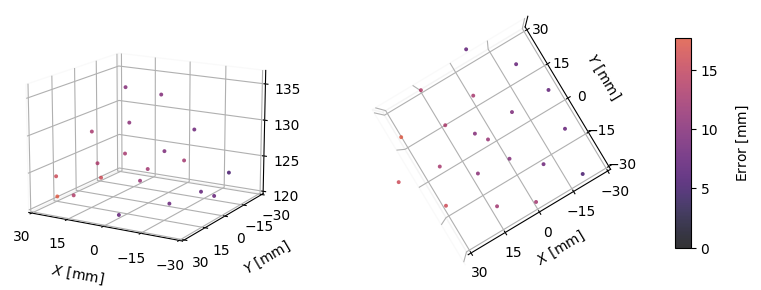


--- Error Summary (Target vs Mocap, datadriven) ---
Mean Error: 11.03 mm
Standard Deviation: 3.20 mm


In [7]:
# Load data
data = np.load("ControlWorkspace_OL_datadriven.npz")
target = data["target"]
mocap = data["mocap"]
# Compute error vs mocap
error_mocap = np.linalg.norm(target - mocap, axis=1)
vmax = np.max(error_mocap)
# Truncate the colormap to first 60% for better contrast
orig_cmap = matplotlib.cm.get_cmap('inferno')
trunc_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'trunc_inferno', orig_cmap(np.linspace(0, 0.6, 256))
)
# Create publication-quality figure
fig = plt.figure(figsize=(8, 3.5))
# ---------------------------
# Plot 1: 3D Perspective View
# ---------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax1.scatter(target[:, 0], target[:, 1], target[:, 2],
                 c=error_mocap, cmap=trunc_cmap, s=8, vmin=0, vmax=vmax,
                 alpha=0.8, edgecolors='none', rasterized=True)
ax1.set_xlabel(r'$X~[\mathrm{mm}]$', labelpad=6)
ax1.set_ylabel(r'$Y~[\mathrm{mm}]$', labelpad=6)
ax1.view_init(elev=15, azim=120)
# Set X and Y axis limits and ticks
ax1.set_xlim(-30, 30)
ax1.set_ylim(-30, 30)
ax1.set_xticks(np.arange(-30, 31, 15))
ax1.set_yticks(np.arange(-30, 31, 15))
ax1.tick_params(axis='x', pad=2)
ax1.tick_params(axis='y', pad=2)
ax1.tick_params(axis='z', pad=2)
# Set Z-axis ticks every 5mm starting from 115
z_min = max(115, int(np.min(target[:, 2])))
z_max = int(np.max(target[:, 2]))
z_ticks = np.arange(z_min, z_max + 5, 5)
ax1.set_zticks(z_ticks)
# Clean 3D panes styling
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#cccccc')
    axis.pane.set_alpha(0.1)
ax1.grid(True, alpha=0.3, linewidth=0.5)
# ---------------------------
# Plot 2: Top-down View
# ---------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(target[:, 0], target[:, 1], target[:, 2],
            c=error_mocap, cmap=trunc_cmap, s=8, vmin=0, vmax=vmax,
            alpha=0.8, edgecolors='none', rasterized=True)
ax2.set_xlabel(r'$X~[\mathrm{mm}]$', labelpad=6)
ax2.set_ylabel(r'$Y~[\mathrm{mm}]$', labelpad=6)
ax2.set_zticks([])
ax2.set_zlabel('')
ax2.view_init(elev=-90, azim=120)
# Set X and Y axis limits and ticks for top-down view
ax2.set_xlim(-30, 30)
ax2.set_ylim(-30, 30)
ax2.set_xticks(np.arange(-30, 31, 15))
ax2.set_yticks(np.arange(-30, 31, 15))
ax2.tick_params(axis='x', pad=2)
ax2.tick_params(axis='y', pad=2)
# Match styling for second plot
for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#cccccc')
    axis.pane.set_alpha(0.1)
ax2.grid(True, alpha=0.3, linewidth=0.5)
# ---------------------------
# Publication-quality colorbar
# ---------------------------
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label(r'$\mathrm{Error}~[\mathrm{mm}]$', labelpad=12)
cbar.ax.tick_params()
# Adjust layout with minimal spacing
plt.subplots_adjust(left=0.05, right=0.9, wspace=0.05)
plt.show()
# ---------------------------
# Summary statistics
# ---------------------------
mean_error = np.mean(error_mocap)
std_error = np.std(error_mocap)
print(f"\n--- Error Summary (Target vs Mocap, datadriven) ---")
print(f"Mean Error: {mean_error:.2f} mm")
print(f"Standard Deviation: {std_error:.2f} mm")

Jacobian Open-Loop

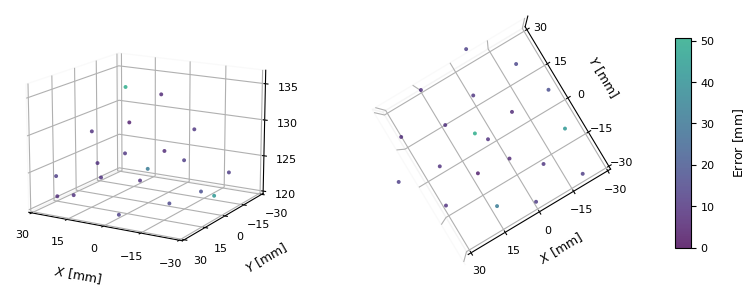


--- Error Summary (Target vs Mocap, jacobian) ---
Mean Error: 15.34 mm
Standard Deviation: 11.88 mm


In [8]:
# Load data
data = np.load("ControlWorkspace_OL_jacobian.npz")
target = data["target"]
mocap = data["mocap"]

# Compute error vs mocap
error_mocap = np.linalg.norm(target - mocap, axis=1)
vmax = np.max(error_mocap)

# Truncate the colormap to first 60% for better contrast
orig_cmap = matplotlib.cm.get_cmap('viridis')
trunc_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'trunc_viridis', orig_cmap(np.linspace(0, 0.6, 256))
)

# Temporarily adjust rcParams for 3D plotting
original_figsize = matplotlib.rcParams['figure.figsize']
original_grid = matplotlib.rcParams['axes.grid']
original_spines_top = matplotlib.rcParams['axes.spines.top']
original_spines_right = matplotlib.rcParams['axes.spines.right']

matplotlib.rcParams.update({
    'figure.figsize': (8, 3.5),
    'axes.grid': False,
    'axes.spines.top': True,
    'axes.spines.right': True
})

# Create publication-quality figure
fig = plt.figure(figsize=(8, 3.5))

# ---------------------------
# Plot 1: 3D Perspective View
# ---------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax1.scatter(target[:, 0], target[:, 1], target[:, 2],
                 c=error_mocap, cmap=trunc_cmap, s=8, vmin=0, vmax=vmax, 
                 alpha=0.8, edgecolors='none', rasterized=True)

ax1.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9, labelpad=6)
ax1.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9, labelpad=6)
ax1.view_init(elev=15, azim=120)
# Set X and Y axis limits and ticks
ax1.set_xlim(-30, 30)
ax1.set_ylim(-30, 30)
ax1.set_xticks(np.arange(-30, 31, 15))
ax1.set_yticks(np.arange(-30, 31, 15))
ax1.tick_params(axis='x', labelsize=8, pad=2)
ax1.tick_params(axis='y', labelsize=8, pad=2)
ax1.tick_params(axis='z', labelsize=8, pad=2)

# Set Z-axis ticks every 5mm starting from 115
z_min = max(115, int(np.min(target[:, 2])))
z_max = int(np.max(target[:, 2]))
z_ticks = np.arange(z_min, z_max + 5, 5)
ax1.set_zticks(z_ticks)

# Clean 3D panes styling
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#cccccc')
    axis.pane.set_alpha(0.1)
ax1.grid(True, alpha=0.3, linewidth=0.5)

# ---------------------------
# Plot 2: Top-down View
# ---------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(target[:, 0], target[:, 1], target[:, 2],
            c=error_mocap, cmap=trunc_cmap, s=8, vmin=0, vmax=vmax,
            alpha=0.8, edgecolors='none', rasterized=True)

ax2.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9, labelpad=6)
ax2.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9, labelpad=6)
ax2.set_zticks([])
ax2.set_zlabel('')
ax2.view_init(elev=-90, azim=120)
# Set X and Y axis limits and ticks for top-down view
ax2.set_xlim(-30, 30)
ax2.set_ylim(-30, 30)
ax2.set_xticks(np.arange(-30, 31, 15))
ax2.set_yticks(np.arange(-30, 31, 15))
ax2.tick_params(axis='x', labelsize=8, pad=2)
ax2.tick_params(axis='y', labelsize=8, pad=2)

# Match styling for second plot
for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#cccccc')
    axis.pane.set_alpha(0.1)
ax2.grid(True, alpha=0.3, linewidth=0.5)

# ---------------------------
# Publication-quality colorbar
# ---------------------------
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label(r'$\mathrm{Error}~[\mathrm{mm}]$', fontsize=9, labelpad=12)
cbar.ax.tick_params(labelsize=8)

# Adjust layout with minimal spacing
plt.subplots_adjust(left=0.05, right=0.9, wspace=0.05)

# Restore original rcParams
matplotlib.rcParams.update({
    'figure.figsize': original_figsize,
    'axes.grid': original_grid,
    'axes.spines.top': original_spines_top,
    'axes.spines.right': original_spines_right
})

plt.show()

# ---------------------------
# Summary statistics
# ---------------------------
mean_error = np.mean(error_mocap)
std_error = np.std(error_mocap)
print(f"\n--- Error Summary (Target vs Mocap, jacobian) ---")
print(f"Mean Error: {mean_error:.2f} mm")
print(f"Standard Deviation: {std_error:.2f} mm")

# Triangle plots

Datadriven

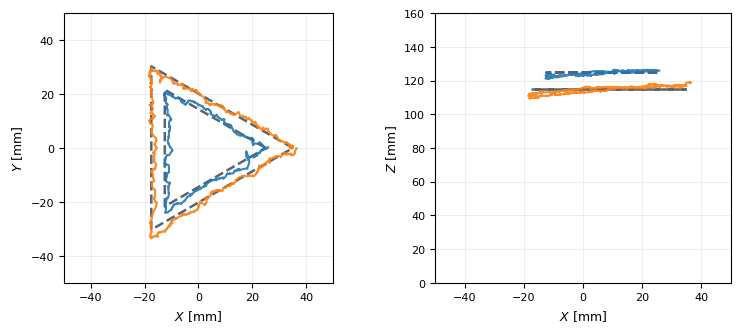

In [9]:
# --- Config ---
n_sides = "3"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_datadriven_mocap.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both triangle heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()


Jacobian-based

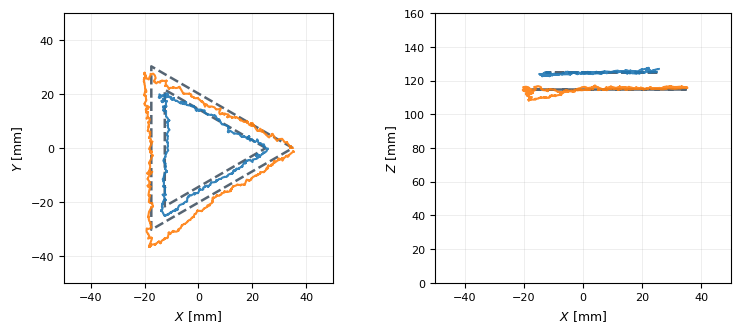

In [10]:
# --- Config ---
n_sides = "3"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_jacobian_mocap.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both triangle heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()


Data-driven Open-Loop

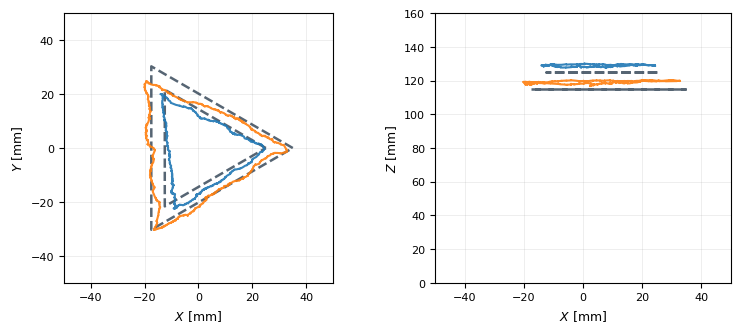

In [11]:
# --- Config ---
n_sides = "3"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_OL_datadriven.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both triangle heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()


Jacobian Open-Loop

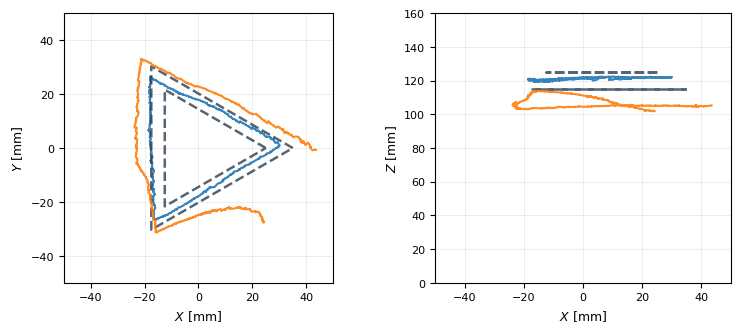

In [12]:
# --- Config ---
n_sides = "3"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_OL_jacobian.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both triangle heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()


## Square plots

Datadriven

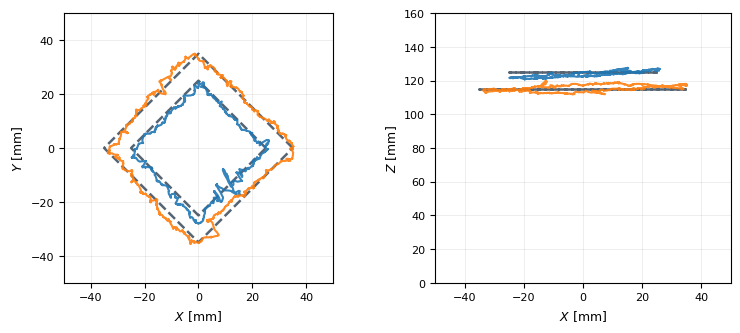

In [13]:
# --- Config ---
n_sides = "4"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_datadriven_mocap.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load mocap data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()

Jacobian-based

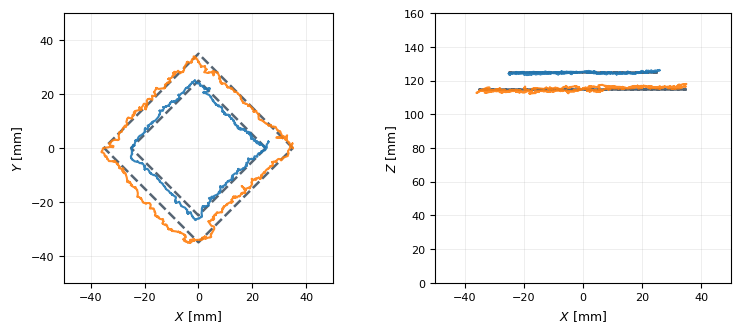

In [14]:
# --- Config ---
n_sides = "4"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_jacobian_mocap.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load mocap data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()

Data-driven Open-Loop

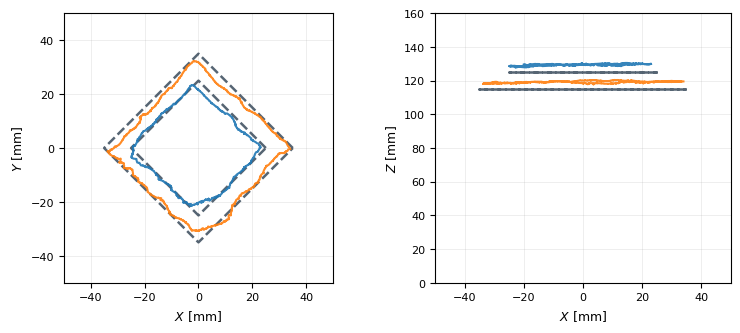

In [15]:
# --- Config ---
n_sides = "4"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_OL_datadriven.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load mocap data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()

Jacobian Open-Loop

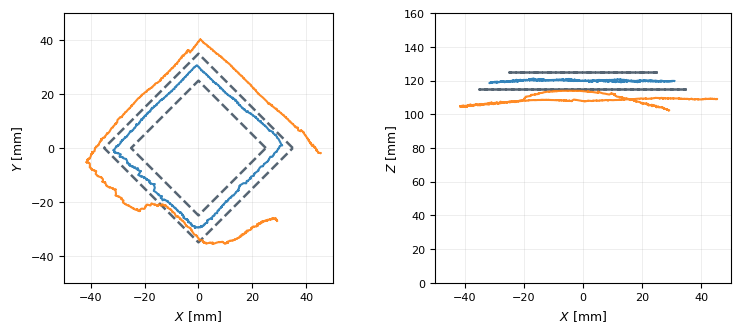

In [16]:
# --- Config ---
n_sides = "4"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_OL_jacobian.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load mocap data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()

## Hexagon plots

Datadriven

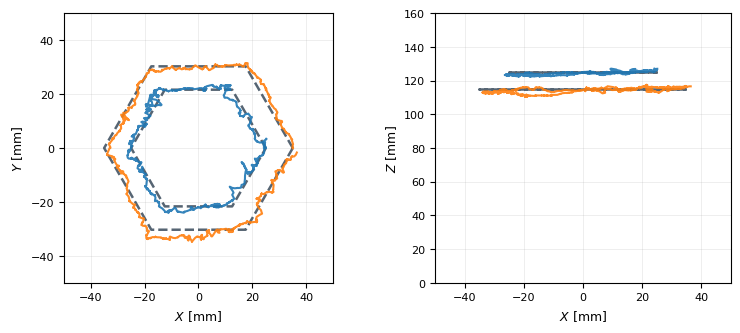

In [17]:
# --- Config ---
n_sides = "6"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_datadriven_mocap.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both polygon heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()

Jacobian-based

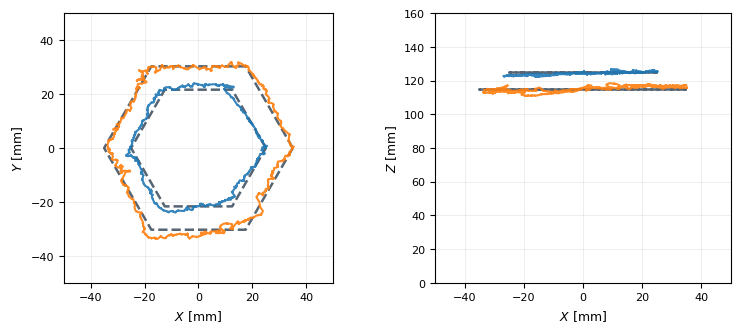

In [18]:
# --- Config ---
n_sides = "6"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_jacobian_mocap.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both polygon heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()

Data-driven Open-Loop

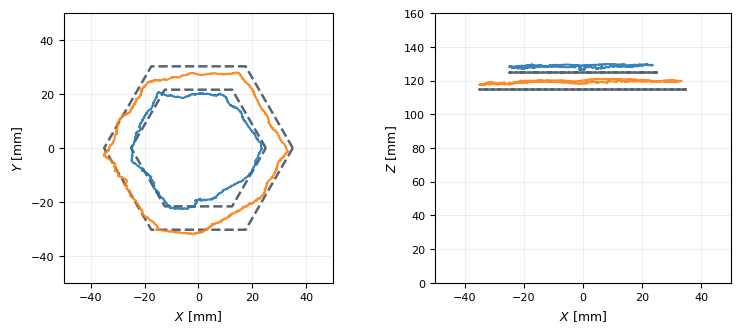

In [19]:
# --- Config ---
n_sides = "6"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_OL_datadriven.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both polygon heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()

Jacobian Open-Loop

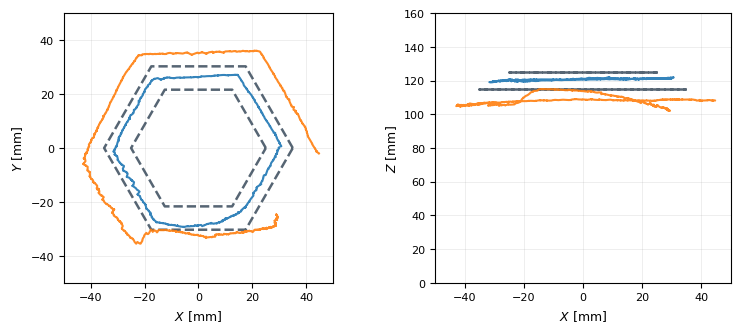

In [20]:
# --- Config ---
n_sides = "6"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_OL_jacobian.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both polygon heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=8)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=9)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=8)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()

## Circle plots

Datadriven

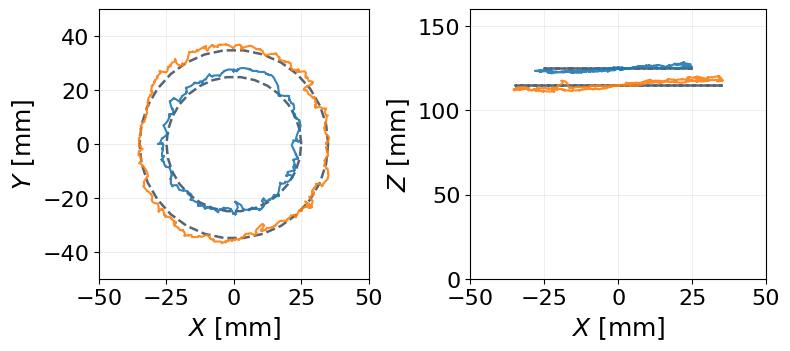

In [21]:
# --- Config ---
n_sides = "30"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_datadriven_mocap.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both polygon heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon (approximates circle with 30 sides)
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=18)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=18)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=16)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=18)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=18)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=16)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()


Jacobian

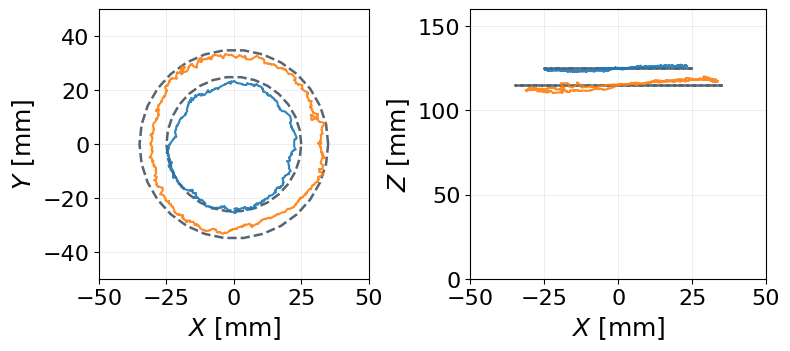

In [22]:
# --- Config ---
n_sides = "30"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_jacobian_mocap.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both polygon heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon (approximates circle with 30 sides)
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=18)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=18)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=16)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=18)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=18)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=16)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()


Data-driven Open-Loop

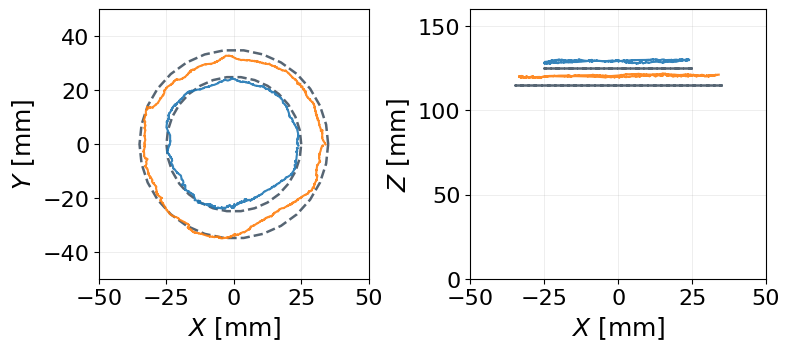

In [23]:
# --- Config ---
n_sides = "30"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_OL_datadriven.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both polygon heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon (approximates circle with 30 sides)
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=18)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=18)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=16)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=18)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=18)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=16)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()


Jacobian Open-Loop

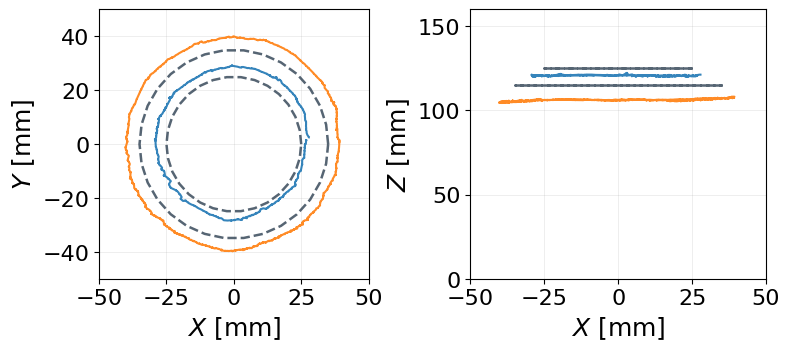

In [24]:
# --- Config ---
n_sides = "30"
heights = ["125", "115"]
base_path = "PolygonWS_{}_{}_OL_jacobian.npz"

# Color and style mapping for publication quality
style_map = {
    "125": {"mocap": "#1f77b4",  "radius": 25},  # Professional blue
    "115": {"mocap": "#ff7f0e",  "radius": 35},  # Professional orange
}
theoretical_color = "#2c3e50"  # Dark blue-gray
theoretical_style = "--"

# Labels per altezza
label_map = {
    "125": "z = 125 mm",
    "115": "z = 115 mm"
}

# Generate polygon vertices (regular polygon, flat on XY plane)
def generate_polygon_vertices(n_sides, radius, height):
    angles = np.linspace(0, 2 * np.pi, int(n_sides), endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = np.full_like(x, fill_value=height)
    return np.stack((x, y, z), axis=1)

# Initialize figure with publication settings
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ax_xy, ax_zx = axes

# Loop over both polygon heights
for height in heights:
    filename = base_path.format(n_sides, height)
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        continue

    # Load data
    data = np.load(filename)
    mocap = data["mocap"]
    label = label_map[height]
    radius = style_map[height]["radius"]

    # Generate theoretical polygon (approximates circle with 30 sides)
    polygon = generate_polygon_vertices(int(n_sides), radius, float(height))
    polygon_closed = np.vstack((polygon, polygon[0]))  # close the loop

    # --- XY view ---
    ax_xy.plot(polygon_closed[:, 0], polygon_closed[:, 1],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_xy.plot(mocap[:, 0], mocap[:, 1], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

    # --- ZX view ---
    ax_zx.plot(polygon_closed[:, 0], polygon_closed[:, 2],
               theoretical_style, color=theoretical_color, linewidth=1.8, 
               alpha=0.8)
    ax_zx.plot(mocap[:, 0], mocap[:, 2], '-', color=style_map[height]["mocap"], 
               linewidth=1.5, alpha=0.9)

# Finalize XY view with publication styling
ax_xy.set_xlim([-50, 50])
ax_xy.set_ylim([-50, 50])
ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=18)
ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=18)
ax_xy.set_aspect("equal")
ax_xy.grid(True, alpha=0.3, linewidth=0.5)
ax_xy.tick_params(labelsize=16)

# Finalize ZX view with publication styling
ax_zx.set_xlim([-50, 50])
ax_zx.set_ylim([0, 160])
ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=18)
ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=18)
ax_zx.set_aspect("auto")
ax_zx.grid(True, alpha=0.3, linewidth=0.5)
ax_zx.tick_params(labelsize=16)

# Apply tight layout with minimal spacing
plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
plt.show()


Barplot

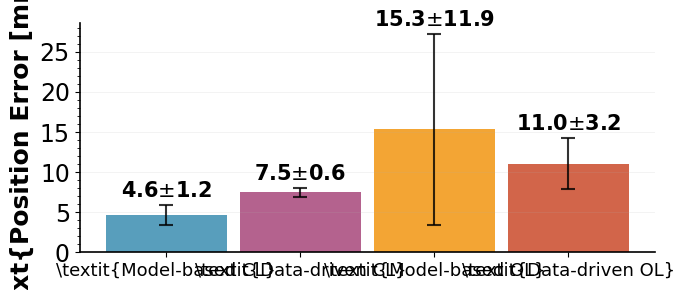

In [25]:
means = [4.63, 7.49, 15.34, 11.03]
stds = [1.24, 0.57, 11.88, 3.20]

labels = [r'\textit{Model-based CL}',
          r'\textit{Data-driven CL}',
          r'\textit{Model-based OL}',
          r'\textit{Data-driven OL}']

fig, ax = plt.subplots(figsize=(7, 3))

x_pos = np.arange(len(labels))
bar_width = 0.9

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

bars = ax.bar(x_pos, means, bar_width, yerr=stds, 
              color=colors, alpha=0.8, capsize=5,
              error_kw={'elinewidth': 1.5, 'capthick': 1.5, 'alpha': 0.8})

for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.5,
            f'{mean:.1f}$\pm${std:.1f}',
            ha='center', va='bottom', fontsize=15, fontweight='bold')

ax.set_ylabel(r'\text{Position Error [mm]}', fontsize=18, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=13)

ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.yaxis.set_minor_locator(plt.MultipleLocator(1))

ax.grid(True, axis='y', which='major', linestyle='-', alpha=0.2, linewidth=0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.set_ylim(bottom=0)
ax.tick_params(axis='y', labelsize=17)

plt.tight_layout()
plt.show()